In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.likelihood import sample_likelihood
from mis_dro.bayes_conjugates import *
from mis_dro.plot import *
import matplotlib as mpl

In [2]:
replication = 0
dataset = "newsvendor"
dgp = "normal"
likelihood = "normal"
posterior = "normal_gamma"
num_observations = 20
num_test_observations = 200
num_likelihood_samples = 50
num_posterior_samples = 5
epsilon = 0.2
dim = 1
contamination = 0.0
generator = np.random.default_rng(seed=replication)

In [3]:
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
data_eval = sample_dgp(
    dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
)

In [4]:
theta_prior = default_prior_params(posterior, dim=dim)
mu_prior, kappa_prior, alpha_prior, beta_prior = 0.0, 1.0, 5, 0.01
theta_prior = (mu_prior, kappa_prior, alpha_prior, beta_prior)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
bas_sample = derive_analytical_posterior_params(
    posterior, theta_posterior
)
bdro_sample = normal_gamma_rvs(num_posterior_samples, *theta_posterior, generator=generator)


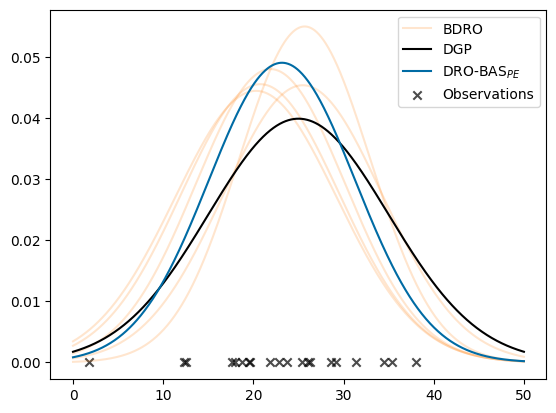

In [5]:
x = np.linspace(0,50,1000)
dgp_mean = 25.0
dgp_std = 10.0
for i in range(num_posterior_samples):
    if i == 0:
        label=AlgorithmName.kl_bdro.value
    else:
        label="_nolegend_"
    plt.plot(x, sp.stats.norm.pdf(x, loc=bdro_sample[i,0],scale=bdro_sample[i,1]), label=label, color=AlgorithmColor.kl_bdro.value, alpha=0.2)
plt.plot(x, sp.stats.norm.pdf(x, loc=dgp_mean, scale=dgp_std), label="DGP", color="black")
plt.plot(x, sp.stats.norm.pdf(x, loc=bas_sample[0,0],scale=bas_sample[0,1]), label=AlgorithmName.kl_dro_bas.value, color=AlgorithmColor.kl_dro_bas.value)
plt.scatter(data, np.zeros(num_observations), marker="x", color="black", label="Observations", alpha=0.7)
plt.legend()

In [6]:
def kl_divergence_1d_normals(mu_1, std_1, mu_2, std_2):
    return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5

def expected_kl_divergence_1d_normals(mu, std, mu_hat, std_hat, G_constant):
    return G_constant + kl_divergence_1d_normals(mu, std, mu_hat, std_hat)

def get_regular_grid(z_samples: np.array, epsilon: float) -> np.array:
    """Get a grid that easily covers the epsilon ball"""
    n_points = 1000
    margin = 0.2
    z_mean = np.mean(z_samples, axis=0)
    x_axis = np.linspace(
        start=min(np.min(z_samples[:, 0]), z_mean[0] - epsilon - margin), 
        stop=max(np.max(z_samples[:, 0]), z_mean[0] + epsilon + margin),
        num=n_points,
    )
    y_axis = np.linspace(
        start=min(np.min(z_samples[:, 1]), z_mean[1] - epsilon - margin),
        stop=max(np.max(z_samples[:, 1]), z_mean[1] + epsilon + margin),
        num=n_points
    )
    xv, yv = np.array(np.meshgrid(x_axis, y_axis))
    return np.array([xv.flatten(), yv.flatten()]).T

In [7]:
z_samples = normal_gamma_rvs(num_posterior_samples, *theta_posterior, generator=generator)
# grid = get_regular_grid(z_samples, epsilon)
xv, yv = np.array(np.meshgrid(np.linspace(15, 35, 1000), np.linspace(0, 20, 1000)))
grid = np.array([xv.flatten(), yv.flatten()]).T
grid.shape

(1000000, 2)

In [8]:
G_constant = get_log_partition_constant(posterior, theta_posterior)
M = np.array([expected_kl_divergence_1d_normals(y[0], y[1], bas_sample[0,0], bas_sample[0,1], G_constant) for y in grid])
in_U1 = grid[M <= epsilon]

def get_convex_hull_polygon_points(points):
    hull = sp.spatial.ConvexHull(points)
    return np.array([points[hull.vertices, 0], points[hull.vertices, 1]]).T

bas_convex_hull_points = get_convex_hull_polygon_points(in_U1)


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_61168/267159308.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_61168/708941202.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


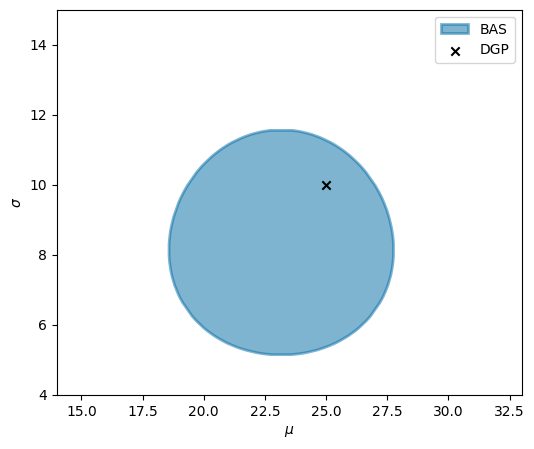

In [21]:
fig, ax = plt.subplots(figsize=(6,5))
# ax.scatter(z_samples[:,0], z_samples[:, 1], alpha=0.3, marker="x")
bas_polygon = mpl.patches.Polygon(bas_convex_hull_points, alpha=0.5, color=AlgorithmColor.kl_dro_bas.value, label="BAS", closed=True, linewidth=2)
ax.add_patch(bas_polygon)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.scatter([dgp_mean], [dgp_std], marker="x", color="black", label="DGP")
ax.set(adjustable="box")
ax.set_xlim(14, 33)
ax.set_ylim(4, 15)
ax.legend()
fig.show()
fig.savefig("/Users/patrick/Experiments/misdro/paper_bas_figures/dro_bas_ambiguity_set.pdf", bbox_inches="tight")

In [10]:
bdro_polygon_points = []
for point in z_samples:
    M = np.array([kl_divergence_1d_normals(y[0], y[1], point[0], point[1]) for y in grid])
    in_U1 = grid[M <= epsilon]
    bdro_polygon_points.append(get_convex_hull_polygon_points(in_U1))


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_61168/267159308.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(std_2 / std_1) + (std_1**2 + (mu_1 - mu_2)**2) / (2 * std_2**2) - 0.5


/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_61168/3513190900.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


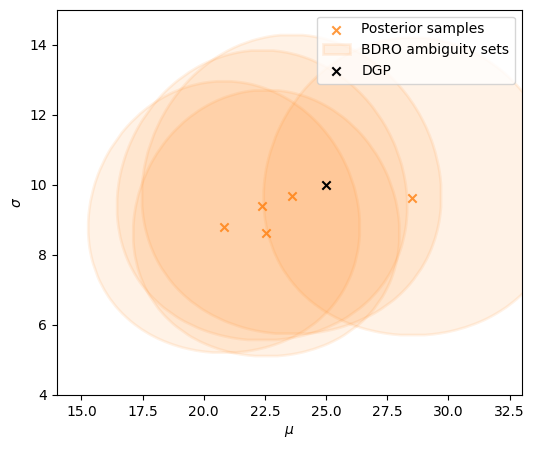

In [22]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(z_samples[:,0], z_samples[:, 1], alpha=0.8, marker="x", label="Posterior samples", color=AlgorithmColor.kl_bdro)
for i, polygon_points in enumerate(bdro_polygon_points):
    if i == 0:
        polygon = mpl.patches.Polygon(polygon_points, alpha=0.1, color=AlgorithmColor.kl_bdro, label="BDRO ambiguity sets", closed=True, linewidth=2)
    else:
        polygon = mpl.patches.Polygon(polygon_points, alpha=0.1, color=AlgorithmColor.kl_bdro, closed=True, linewidth=2)
    ax.add_patch(polygon)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.scatter([dgp_mean], [dgp_std], marker="x", color="black", label="DGP")
# ax.set(adjustable="box", aspect='equal')
ax.set(adjustable="box")
# ax.set_box_aspect(1)
ax.set_xlim(14, 33)
ax.set_ylim(4, 15)
ax.legend(loc="upper right")
fig.show()
fig.savefig("/Users/patrick/Experiments/misdro/paper_bas_figures/bdro_ambiguity_set.pdf", bbox_inches="tight")